In [1]:
# ══════════════════════════════════════════════════════════
# CELLULE 1 — Installations (corrigée)
# ══════════════════════════════════════════════════════════
!pip install -q transformers==4.40.0 timm easyocr
!pip install -q torch torchvision

# Redémarrer le runtime après cette cellule !
print("✅ Installations terminées")
print("⚠️  IMPORTANT : Aller dans Exécution → Redémarrer la session")
print("   Puis ré-exécuter à partir de la cellule 2")

✅ Installations terminées
⚠️  IMPORTANT : Aller dans Exécution → Redémarrer la session
   Puis ré-exécuter à partir de la cellule 2


In [2]:
# ══════════════════════════════════════════════════════════
# CELLULE 2 — Téléchargement du modèle depuis Drive
# ══════════════════════════════════════════════════════════
import gdown, os

# ✅ Uniquement l'ID, pas le lien complet
FILE_ID  = "13T5OrL25R4oONoY-T8Gnq5MRQUei2vLW"
PTH_PATH = "bank_doc_classifier_multimodal.pth"

if not os.path.exists(PTH_PATH):
    print("⬇️  Téléchargement du modèle...")
    gdown.download(id=FILE_ID, output=PTH_PATH, quiet=False)  # ✅ paramètre id= au lieu de url
    print("✅ Modèle téléchargé")
else:
    print("✅ Modèle déjà présent dans la session")

✅ Modèle déjà présent dans la session


In [3]:
# ══════════════════════════════════════════════════════════
# CELLULE 3 — Chargement du modèle (corrigée)
# ══════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms
import timm, easyocr
import matplotlib.pyplot as plt

# Import transformers APRÈS redémarrage runtime
from transformers import AutoTokenizer, AutoModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️  Device : {DEVICE}")

# Vérification version transformers
import transformers
print(f"📦 Transformers version : {transformers.__version__}")
assert transformers.__version__.startswith("4.40"), \
    f"❌ Mauvaise version ! Attendu 4.40.x, obtenu {transformers.__version__}. Relance la cellule 1."

# ── Architecture ───────────────────────────────────────────
class MultimodalBankClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vision_model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=0)
        visual_dim        = self.vision_model.num_features
        self.text_model   = AutoModel.from_pretrained("bert-base-multilingual-cased")
        text_dim          = self.text_model.config.hidden_size
        self.fusion       = nn.Sequential(
            nn.Linear(visual_dim + text_dim, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    def forward(self, image, input_ids, attention_mask):
        v = self.vision_model(image)
        t = self.text_model(input_ids=input_ids,
                            attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.fusion(torch.cat([v, t], dim=1))

# ── Charger checkpoint ─────────────────────────────────────
print("⏳ Chargement des poids...")
checkpoint  = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
le          = checkpoint['label_encoder']
num_classes = checkpoint['num_classes']
img_size    = checkpoint['img_size']
max_text    = checkpoint['max_text_len']

model = MultimodalBankClassifier(num_classes=num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()
print("✅ Modèle chargé")

# ── Tokenizer ──────────────────────────────────────────────
print("⏳ Chargement tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
print("✅ Tokenizer prêt")

# ── EasyOCR ────────────────────────────────────────────────
print("⏳ Chargement EasyOCR...")
ocr_fr = easyocr.Reader(["fr", "en"], gpu=torch.cuda.is_available(), verbose=False)
ocr_ar = easyocr.Reader(["ar", "en"], gpu=torch.cuda.is_available(), verbose=False)
print("✅ OCR prêt")

# ── Transform ──────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

LABELS_FR = {
    "rib":                   "RIB",
    "cheque":                "Chèque",
    "acte_de_naissance":     "Acte de Naissance",
    "tableau_amortissement": "Tableau d'Amortissement",
    "assurance":             "Assurance",
    "attestation_de_solde":  "Attestation de Solde",
    "acte_heredite":         "Acte d'Hérédité",
}

print(f"\n🎉 Tout est prêt !")
print(f"📋 Classes : {[LABELS_FR.get(c, c) for c in le.classes_]}")
print(f"📊 Accuracy validation : {checkpoint['val_acc']:.4f}")
print(f"\n➡️  Exécutez la cellule 4 pour tester une image")


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

⚙️  Device : cpu
📦 Transformers version : 4.40.0
⏳ Chargement des poids...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

✅ Modèle chargé
⏳ Chargement tokenizer...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer prêt
⏳ Chargement EasyOCR...


✅ OCR prêt

🎉 Tout est prêt !
📋 Classes : ["Acte d'Hérédité", 'acte_naissance', 'Assurance', 'attestation_solde', 'Chèque', 'RIB', "Tableau d'Amortissement"]
📊 Accuracy validation : 1.0000

➡️  Exécutez la cellule 4 pour tester une image


📤 Uploadez votre document (JPG ou PNG) :


Saving WhatsApp Image 2026-03-04 at 12.45.23.jpeg to WhatsApp Image 2026-03-04 at 12.45.23.jpeg

🔍 Analyse : WhatsApp Image 2026-03-04 at 12.45.23.jpeg


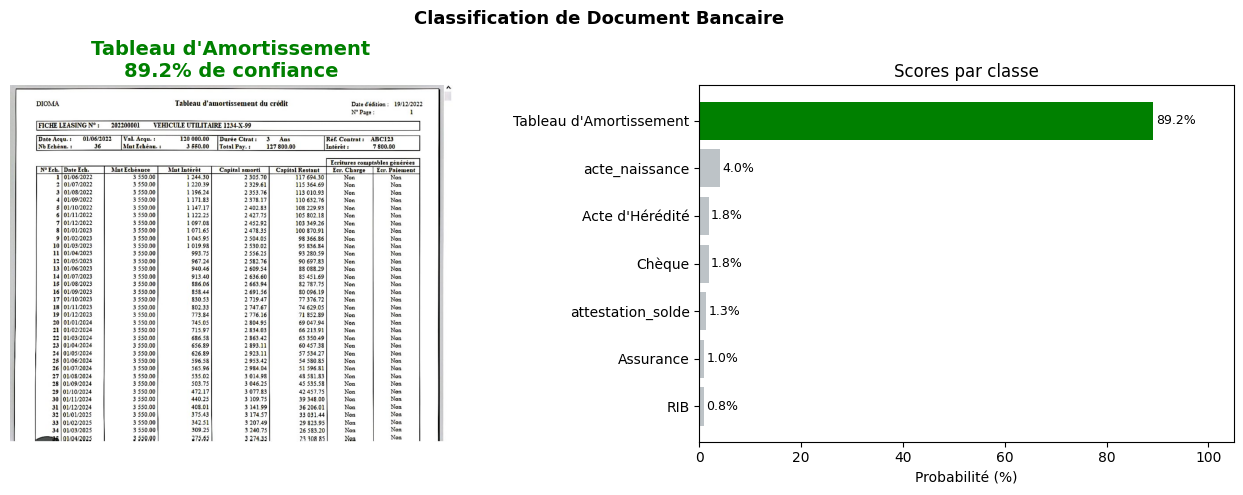

──────────────────────────────────────────────────
🏆 Classe prédite  : Tableau d'Amortissement
📊 Confiance       : 89.2%
📝 Texte OCR       : DIOMA Tableau d'amortissement du crédit Date dèdition 19/12/2022 Pag? FICHE LEASING N' 202200001 VEHCULE UTILIIAIRE 12J4-X-99 Da
──────────────────────────────────────────────────


In [4]:
# ══════════════════════════════════════════════════════════
# CELLULE 4 — 🎯 TESTER UNE IMAGE
# ✅ Ré-exécuter uniquement cette cellule pour chaque nouvelle image
# ══════════════════════════════════════════════════════════
from google.colab import files

def predict(img_path):
    img        = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)

    # OCR bilingue fr + ar
    text = " ".join(
        ocr_fr.readtext(img_path, detail=0, paragraph=True) +
        ocr_ar.readtext(img_path, detail=0, paragraph=True)
    )[:max_text] or "[NO_TEXT]"

    # Tokenisation
    tok = tokenizer(text, max_length=max_text, padding="max_length",
                    truncation=True, return_tensors="pt")

    # Prédiction
    with torch.no_grad():
        probs = F.softmax(
            model(img_tensor,
                  tok["input_ids"].to(DEVICE),
                  tok["attention_mask"].to(DEVICE)),
            dim=1
        ).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))

    label = LABELS_FR.get(le.classes_[pred_idx], le.classes_[pred_idx])
    conf  = probs[pred_idx] * 100
    color = "green" if conf >= 80 else "orange" if conf >= 50 else "red"

    # ── Affichage ──────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.imshow(Image.open(img_path))
    ax1.axis("off")
    ax1.set_title(f"{label}\n{conf:.1f}% de confiance",
                  fontsize=14, fontweight="bold", color=color)

    sorted_idx = np.argsort(probs)[::-1]
    bars = ax2.barh(
        [LABELS_FR.get(le.classes_[i], le.classes_[i]) for i in sorted_idx],
        [probs[i] * 100 for i in sorted_idx],
        color=[color if i == pred_idx else "#BDC3C7" for i in sorted_idx]
    )
    for bar, idx in zip(bars, sorted_idx):
        ax2.text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height() / 2,
                 f"{probs[idx]*100:.1f}%", va="center", fontsize=9)

    ax2.set_xlabel("Probabilité (%)")
    ax2.set_title("Scores par classe")
    ax2.set_xlim(0, 105)
    ax2.invert_yaxis()
    plt.suptitle("Classification de Document Bancaire",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Résumé ─────────────────────────────────────────────
    print("─" * 50)
    print(f"🏆 Classe prédite  : {label}")
    print(f"📊 Confiance       : {conf:.1f}%")
    print(f"📝 Texte OCR       : {text[:250]}")
    print("─" * 50)

# ── Upload et test ─────────────────────────────────────────
print("📤 Uploadez votre document (JPG ou PNG) :")
uploaded = files.upload()
for img_path in uploaded.keys():
    print(f"\n🔍 Analyse : {img_path}")
    predict(img_path)